<a href="https://colab.research.google.com/github/devanshomar60-colla/DSML-Training/blob/main/Module-1/MyAnotomy.2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("imdevskp/corona-virus-report")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'corona-virus-report' dataset.
Path to dataset files: /kaggle/input/corona-virus-report


In [ ]:
import os
print(os.listdir(path))

['covid_19_clean_complete.csv', '.nfs00000000c953b341000000aa', 'country_wise_latest.csv', 'day_wise.csv', 'usa_county_wise.csv', 'worldometer_data.csv', 'full_grouped.csv']


In [ ]:
import pandas as pd
file_path= os.path.join(path,"covid_19_clean_complete.csv")
df=pd.read_csv(file_path)
df.tail(2)

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
49066,NaN,Tajikistan,38.861,71.2761,2020-07-27,7235,60,6028,1147,Europe
49067,NaN,Lesotho,-29.610,28.2336,2020-07-27,505,12,128,365,Africa


In [ ]:
df.head(5)


,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [ ]:
# Dataset ka shape batata hai
# Pehla value = total rows
# Dusra value = total columns
print("shape of data(rows and columns):\n",df.shape)

print("columns:\n",df.columns)# Dataset ke saare column names batata hai

# Numerical columns ka statistical summary deta hai
# Isme count, mean, standard deviation, minimum,
# 25%, 50%, 75% percentile aur maximum values hoti hain
print("\n",df.describe)

shape of data(rows and columns):
 (49068, 10)
columns:
 Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')

 <bound method NDFrame.describe of       Province/State         Country/Region        Lat       Long        Date  \
0                NaN            Afghanistan  33.939110  67.709953  2020-01-22   
1                NaN                Albania  41.153300  20.168300  2020-01-22   
2                NaN                Algeria  28.033900   1.659600  2020-01-22   
3                NaN                Andorra  42.506300   1.521800  2020-01-22   
4                NaN                 Angola -11.202700  17.873900  2020-01-22   
...              ...                    ...        ...        ...         ...   
49063            NaN  Sao Tome and Principe   0.186400   6.613100  2020-07-27   
49064            NaN                  Yemen  15.552727  48.516388  2020-07-27   
49065            NaN   

In [ ]:
print("sum of null values:\n",df.isnull().sum())# Check karta hai ki dataset ke har column me kitne NULL/Missing values hain

print("\n Sum of duplicate values\n",df.duplicated().sum())#Check karta hai ki dataset me kitni completely duplicate rows hain

print("information of dataset\n",df.info())# Dataset ki basic information show karta hai

df["Date"]=pd.to_datetime(df["Date"])# "Date" column ko proper DateTime format me convert karta hai

print("information of dataset\n",df.info())# Conversion ke baad dataset ki information dobara check karta hai

sum of null values:
 Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64

 Sum of duplicate values
 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory u

In [ ]:
#since we have null values in
#sum of null values:
#Province/State    34404
#so we will fill it with unknown
df["Province/State"]=df["Province/State"].fillna("unkown")# here we are replacing the null values in the Province/State with unknown

df.isnull().sum()# here we are checking if we have filled the null value or not
print(df.head(3))

  Province/State Country/Region       Lat       Long       Date  Confirmed  \
0         unkown    Afghanistan  33.93911  67.709953 2020-01-22          0   
1         unkown        Albania  41.15330  20.168300 2020-01-22          0   
2         unkown        Algeria  28.03390   1.659600 2020-01-22          0   

   Deaths  Recovered  Active             WHO Region  
0       0          0       0  Eastern Mediterranean  
1       0          0       0                 Europe  
2       0          0       0                 Africa  


In [ ]:
# Province/State ke according data ko group karta hai
# groupby() -> same Province/State wali rows ko ek group me rakhta hai
# ["Confirmed", "Deaths", "Recovered", "Active"] -> in columns ka data select karta hai
# sum() -> har Province/State ke values ka total nikalta hai
# reset_index() -> Province/State ko normal column bana deta hai

state_data = df.groupby("Province/State")[["Confirmed", "Deaths", "Recovered", "Active"]].sum().reset_index()
print(state_data)

                  Province/State  Confirmed    Deaths  Recovered     Active
0                        Alberta     751219     14245          0     736974
1                       Anguilla        361         0        290         71
2                          Anhui     172497      1007     155768      15722
3                          Aruba      12090       289       9629       2172
4   Australian Capital Territory      13174       339      11264       1571
..                           ...        ...       ...        ...        ...
74                      Xinjiang      14160       474      11280       2406
75                         Yukon       1276         0          0       1276
76                        Yunnan      32118       319      28400       3399
77                      Zhejiang     220824       159     198777      21888
78                        unkown  803320064  41984417  375714958  385620689

[79 rows x 5 columns]


In [ ]:
# Death Rate calculate karta hai
# Death Rate = Deaths / Confirmed
# Result ko state_data me "Death_Rate" naam ke new column me store karta hai

state_data["Death_Rate"] = state_data["Deaths"] / state_data["Confirmed"]
# Death_Rate ki values ko 2 decimal places tak round karta hai
state_data["Death_Rate"] = state_data["Death_Rate"].round(2)
print(state_data)

                  Province/State  Confirmed    Deaths  Recovered     Active  \
0                        Alberta     751219     14245          0     736974   
1                       Anguilla        361         0        290         71   
2                          Anhui     172497      1007     155768      15722   
3                          Aruba      12090       289       9629       2172   
4   Australian Capital Territory      13174       339      11264       1571   
..                           ...        ...       ...        ...        ...   
74                      Xinjiang      14160       474      11280       2406   
75                         Yukon       1276         0          0       1276   
76                        Yunnan      32118       319      28400       3399   
77                      Zhejiang     220824       159     198777      21888   
78                        unkown  803320064  41984417  375714958  385620689   

    Death_Rate  
0         0.02  
1         0.00  


In [ ]:
state_data["Recovered_Rate"] = state_data["Recovered"] / state_data["Confirmed"]
state_data["Recovered_Rate"] = state_data["Recovered_Rate"].round(2)
print(state_data)

                  Province/State  Confirmed    Deaths  Recovered     Active  \
0                        Alberta     751219     14245          0     736974   
1                       Anguilla        361         0        290         71   
2                          Anhui     172497      1007     155768      15722   
3                          Aruba      12090       289       9629       2172   
4   Australian Capital Territory      13174       339      11264       1571   
..                           ...        ...       ...        ...        ...   
74                      Xinjiang      14160       474      11280       2406   
75                         Yukon       1276         0          0       1276   
76                        Yunnan      32118       319      28400       3399   
77                      Zhejiang     220824       159     198777      21888   
78                        unkown  803320064  41984417  375714958  385620689   

    Death_Rate  Recovered_Rate  
0         0.02    

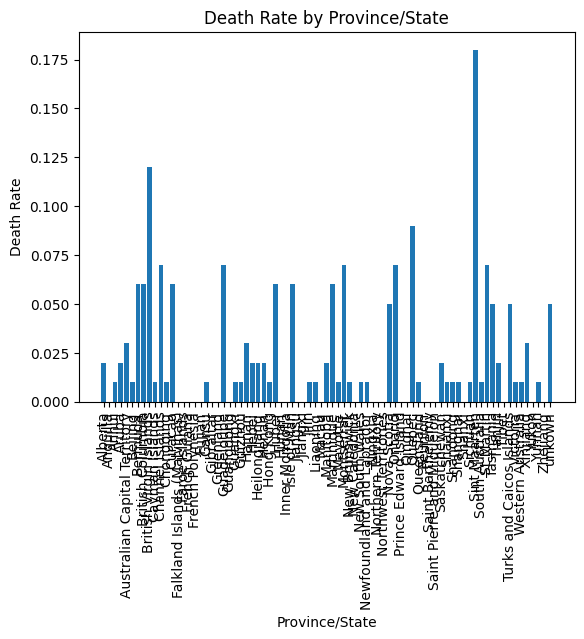

In [ ]:
#to create a bar chart
import matplotlib.pyplot as plt
# Province/State ke according Death Rate ka bar chart
plt.bar(state_data["Province/State"], state_data["Death_Rate"])
# X-axis ka label
plt.xlabel("Province/State")
# Y-axis ka label
plt.ylabel("Death Rate")
# Chart ka title
plt.title("Death Rate by Province/State")
# X-axis labels ko readable banata hai
plt.xticks(rotation=90)
# Chart display karta hai
plt.show()

      Province/State  Confirmed
78            unkown  803320064
30             Hubei   11473248
54            Quebec    4934478
51           Ontario    3100515
0            Alberta     751219
45   New South Wales     384636
7   British Columbia     298207
72          Victoria     279524
22         Guangdong     268051
15     French Guiana     226554


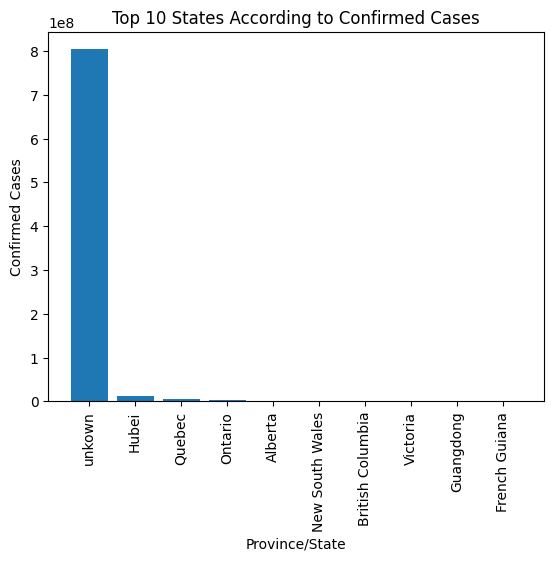

In [ ]:
# Confirmed cases ke according Top 10 states
top_10 = state_data.sort_values("Confirmed", ascending=False).head(10)

print(top_10[["Province/State", "Confirmed"]])

import matplotlib.pyplot as plt

# Top 10 states ka bar chart
plt.bar(top_10["Province/State"], top_10["Confirmed"])

# X-axis ka label
plt.xlabel("Province/State")

# Y-axis ka label
plt.ylabel("Confirmed Cases")

# Chart ka title
plt.title("Top 10 States According to Confirmed Cases")

# State names ko readable banane ke liye
plt.xticks(rotation=90)

# Chart show
plt.show()

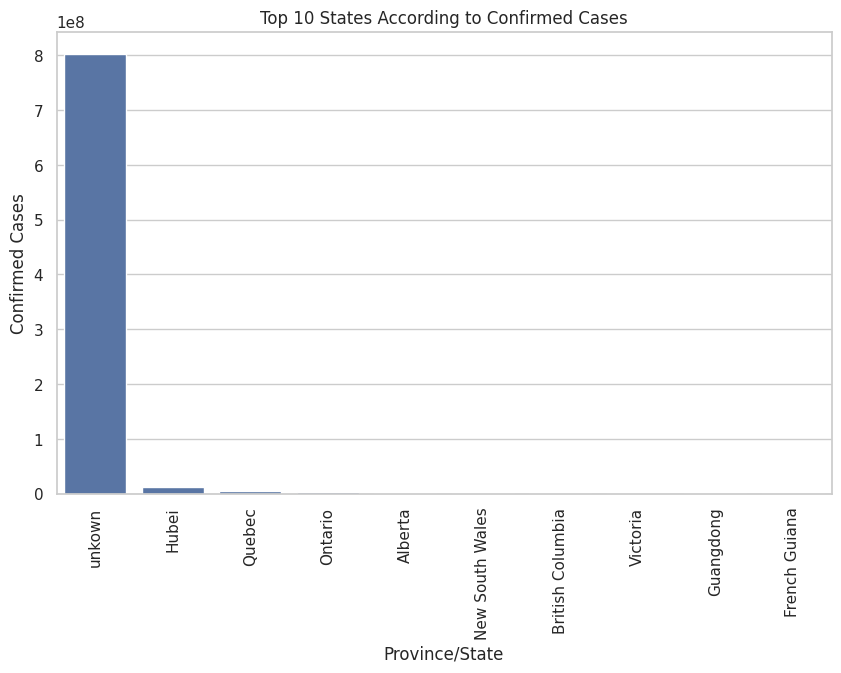

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))
sns.barplot(x="Province/State", y="Confirmed", data=top_10)
plt.xlabel("Province/State")
plt.ylabel("Confirmed Cases")
plt.title("Top 10 States According to Confirmed Cases")
plt.xticks(rotation=90)
plt.show()